# OULAD EDA (2) — VLE 온라인 참여도 분석

`studentVle.csv`는 **1,065만 행**(≈450MB)의 클릭 로그다.
학생별 온라인 학습환경(VLE) 상호작용을 집계해 **참여도와 학습 결과**의 관계를 본다.

> 대용량이므로 필요한 컬럼만, dtype를 지정해 로드한다.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

# 한글 폰트 설정 (맑은 고딕) — set_theme 이후에 지정해야 덮어쓰이지 않음
plt.rc("font", family="Malgun Gothic")
# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams["figure.figsize"] = (9, 5)
DATA = Path("..") / "data"

## 1. 대용량 클릭 로그 로드 (dtype 최적화)

In [12]:
dtypes = {
    "code_module": "category", "code_presentation": "category",
    "id_student": "int32", "id_site": "int32",
    "date": "int16", "sum_click": "int16",
}
vle = pd.read_csv(DATA / "studentVle.csv", dtype=dtypes)
print(vle.shape)
print(vle.memory_usage(deep=True).sum() / 1e6, "MB")
vle.head()


(10655280, 6)
149.175104 MB


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


## 2. 학생별 참여도 집계

In [13]:
agg = vle.groupby("id_student").agg(
    total_clicks=("sum_click", "sum"),
    active_days=("date", "nunique"),
    n_materials=("id_site", "nunique"),
    first_day=("date", "min"),
    last_day=("date", "max"),
).reset_index()
agg["clicks_per_active_day"] = agg["total_clicks"] / agg["active_days"]
print(agg.shape)
agg.describe().round(1)


(26074, 7)


,id_student,total_clicks,active_days,n_materials,first_day,last_day,clicks_per_active_day
count,26074.0,26074.0,26074.0,26074.0,26074.0,26074.0,26074.0
mean,708745.3,1518.9,66.6,75.2,-8.5,183.6,19.7
std,552954.4,1936.0,56.6,62.0,12.6,87.6,11.8
min,6516.0,1.0,1.0,1.0,-25.0,-25.0,1.0
25%,506717.0,298.0,21.0,30.0,-17.0,115.0,11.5
50%,590115.0,824.0,52.0,56.0,-10.0,229.0,17.0
75%,645918.2,2018.0,99.0,104.0,-4.0,244.0,25.4
max,2698588.0,28615.0,286.0,579.0,238.0,269.0,157.7


## 3. 참여도 분포 (로그 스케일)

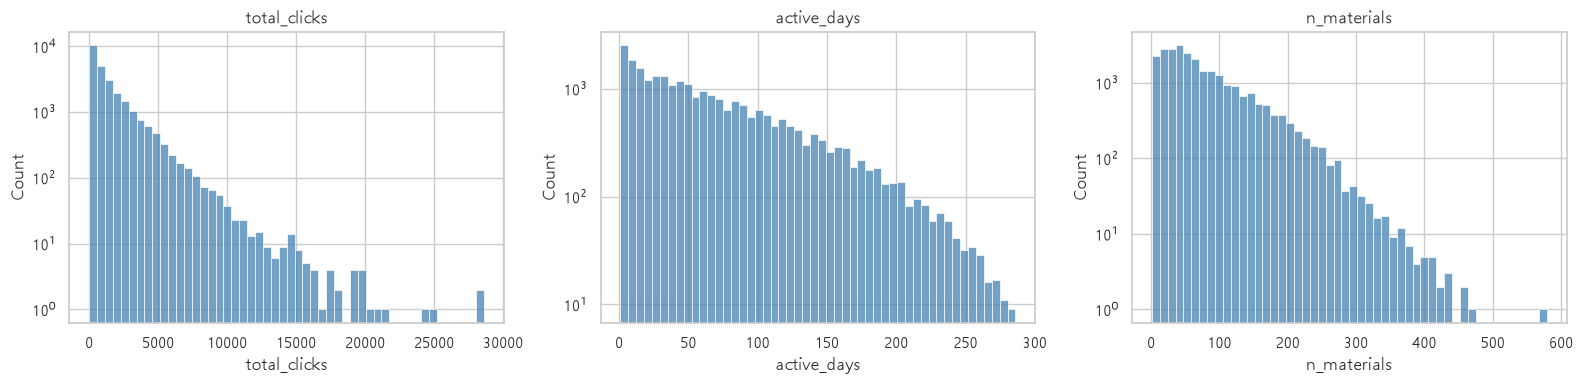

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["total_clicks", "active_days", "n_materials"]):
    sns.histplot(agg[col], bins=50, ax=ax, color="steelblue")
    ax.set_yscale("log")
    ax.set_title(col)
plt.tight_layout(); plt.show()


## 4. 참여도 vs 최종 결과

In [ ]:
info = pd.read_csv(DATA / "studentInfo.csv")
# 같은 학생이 여러 모듈 등록 가능 → 학생 단위 결과는 대표값(최빈)으로 단순화
res = (info.groupby("id_student")["final_result"]
       .agg(lambda s: s.value_counts().index[0]).reset_index())
df = agg.merge(res, on="id_student", how="inner")
order = ["Distinction", "Pass", "Fail", "Withdrawn"]
df["final_result"] = pd.Categorical(df["final_result"], categories=order, ordered=True)
print(df.shape)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="final_result", y="total_clicks", order=order,
            hue="final_result", palette="viridis", legend=False, ax=axes[0])
axes[0].set_yscale("log"); axes[0].set_title("총 클릭 수 (log)")

sns.boxplot(data=df, x="final_result", y="active_days", order=order,
            hue="final_result", palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("활동 일수")
plt.tight_layout(); plt.show()


In [ ]:
df.groupby("final_result", observed=True)[
    ["total_clicks", "active_days", "n_materials", "clicks_per_active_day"]
].median().round(1)


## 5. 시간에 따른 참여도 (코스 진행 주차별)

In [ ]:
# date는 코스 시작 대비 일수. 주 단위로 묶어 전체 클릭 추이 확인
vle_pos = vle[vle["date"] >= 0].copy()
vle_pos["week"] = (vle_pos["date"] // 7).astype("int16")
weekly = vle_pos.groupby("week")["sum_click"].sum()
ax = weekly.plot(marker=".")
ax.set_title("코스 진행 주차별 전체 클릭 수")
ax.set_xlabel("주차"); ax.set_ylabel("총 클릭")
plt.tight_layout(); plt.show()


In [ ]:
# 결과 그룹별 초반(0~4주) 참여도 — 조기 이탈 신호 탐색
early = vle_pos[vle_pos["week"] <= 4].groupby("id_student")["sum_click"].sum().rename("early_clicks")
df2 = df.merge(early, on="id_student", how="left").fillna({"early_clicks": 0})
sns.boxplot(data=df2, x="final_result", y="early_clicks", order=order,
            hue="final_result", palette="rocket", legend=False)
plt.yscale("log")
plt.title("초반 4주 클릭 수 vs 최종 결과 (조기 신호)")
plt.tight_layout(); plt.show()


## 6. 활동 유형(activity_type)별 참여

In [ ]:
vle_meta = pd.read_csv(DATA / "vle.csv")
merged = vle.merge(vle_meta[["id_site", "activity_type"]], on="id_site", how="left")
act = merged.groupby("activity_type")["sum_click"].sum().sort_values(ascending=False)
ax = act.plot(kind="barh", color=sns.color_palette("mako", len(act)))
ax.set_title("활동 유형별 총 클릭 수")
ax.set_xlabel("총 클릭")
plt.tight_layout(); plt.show()
act


## 7. 요약

- 참여도 지표(총 클릭·활동 일수·자원 수)는 **성공 그룹에서 뚜렷하게 높음**.
- **초반 4주 참여도**만으로도 결과 그룹이 갈려 → 조기 경보(early-warning) 모델의 핵심 피처.
- 활동 유형 중 특정 콘텐츠(oucontent 등)에 클릭이 집중 → 콘텐츠 설계 인사이트.
- **다음 단계:** 노트북1의 인구통계 + 이 노트북의 참여도 피처를 결합해 이탈/실패 예측 모델링.
